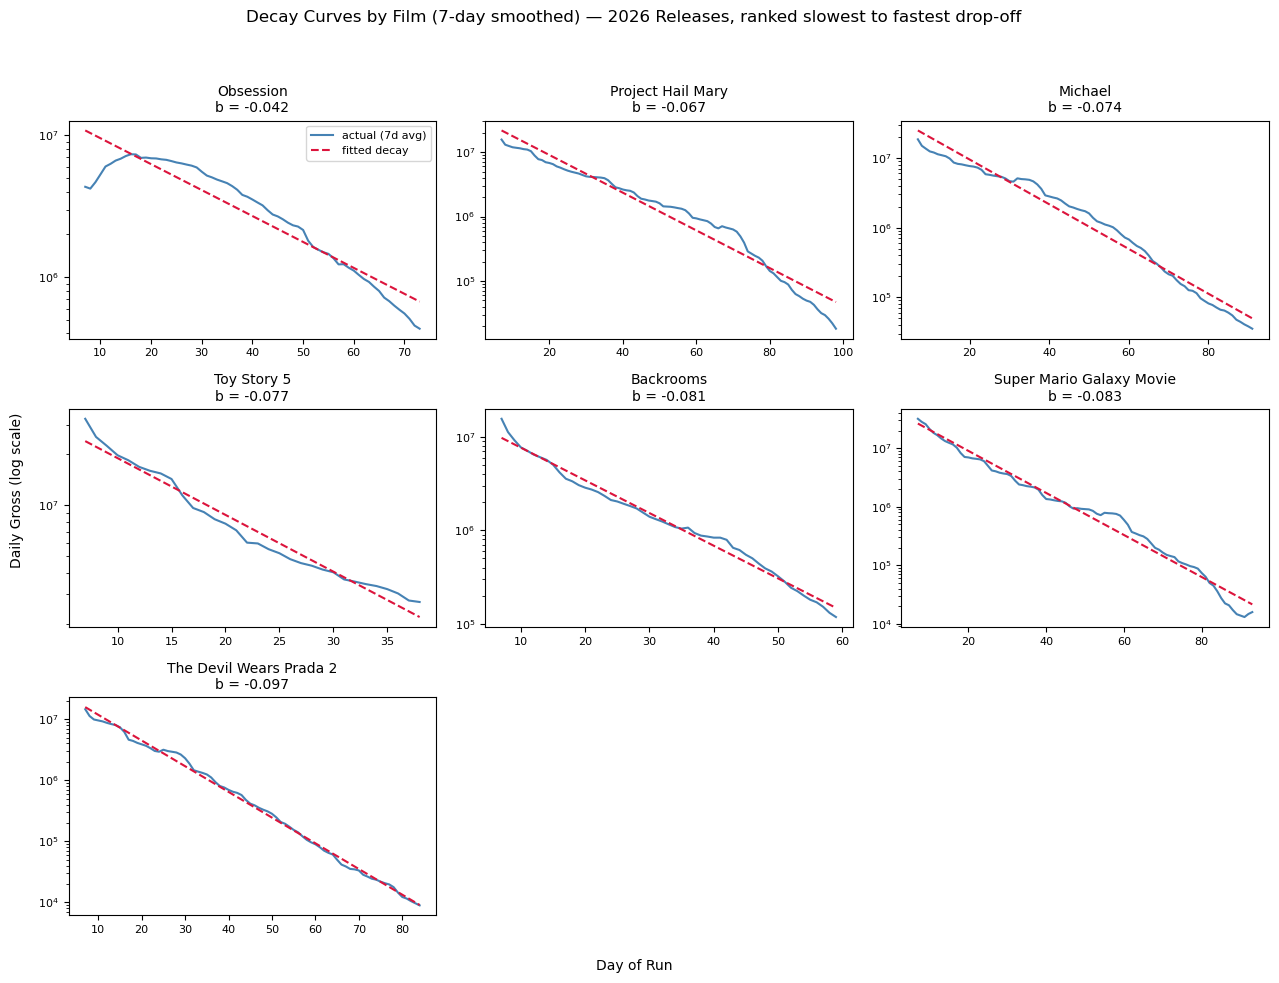

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('bom_daily/all_films_daily.csv')

films_2026 = ['The Odyssey', 'Obsession', 'Backrooms', 'Toy Story 5',
              'Michael', 'The Devil Wears Prada 2', 'Project Hail Mary',
              'Super Mario Galaxy Movie']

fits = {}
for title in films_2026:
    d = df[df['title'] == title].sort_values('day_of_run')
    d = d.assign(smooth=d['daily_gross'].rolling(7, min_periods=7).mean()).dropna(subset=['smooth'])
    if len(d) < 5:
        continue
    x = d['day_of_run'].values
    y = d['smooth'].values
    b, log_a = np.polyfit(x, np.log(y), 1)
    fits[title] = (x, y, log_a, b)

order = sorted(fits, key=lambda t: -fits[t][3]) 

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for i, title in enumerate(order):
    x, y, log_a, b = fits[title]
    ax = axes[i]
    ax.plot(x, y, color='steelblue', lw=1.5, label='actual (7d avg)')
    ax.plot(x, np.exp(log_a) * np.exp(b * x), color='crimson', lw=1.5, ls='--', label='fitted decay')
    ax.set_yscale('log')
    ax.set_title(f"{title}\nb = {b:.3f}", fontsize=10)
    ax.tick_params(labelsize=8)

for j in range(len(order), len(axes)):
    axes[j].axis('off')

axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('Decay Curves by Film (7-day smoothed) — 2026 Releases, ranked slowest to fastest drop-off', fontsize=12)
fig.text(0.5, 0.02, 'Day of Run', ha='center')
fig.text(0.02, 0.5, 'Daily Gross (log scale)', va='center', rotation='vertical')
plt.tight_layout(rect=[0.03, 0.04, 1, 0.95])
plt.savefig('decay_grid.png', dpi=150)

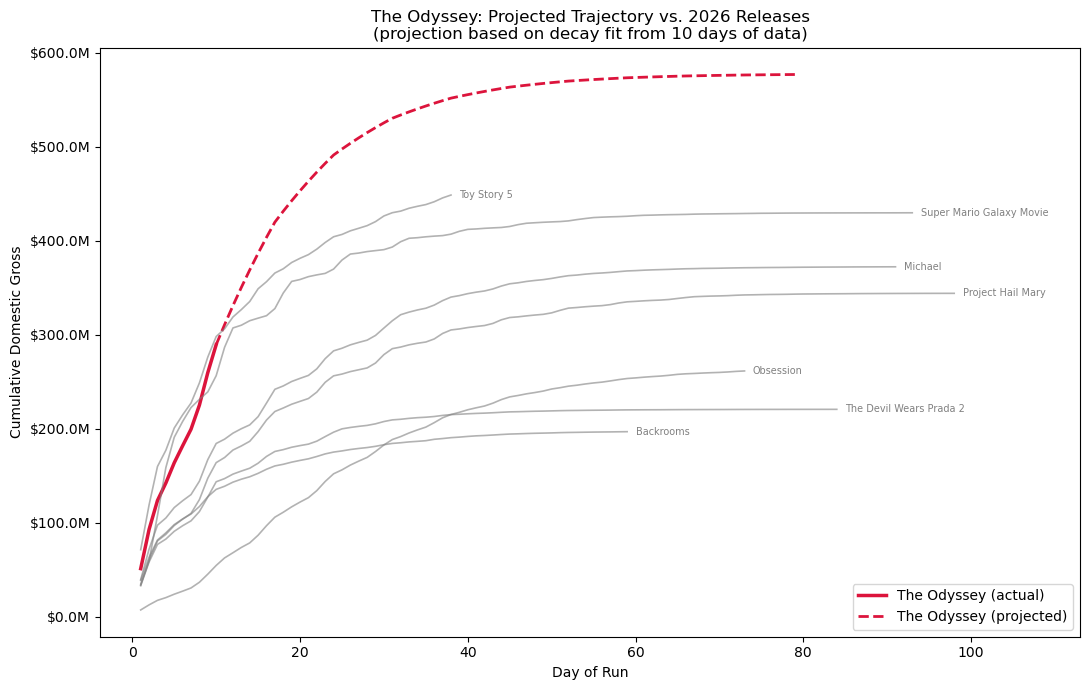

In [12]:
from matplotlib.ticker import FuncFormatter

small_2026 = ['Obsession', 'Backrooms', 'Toy Story 5', 'Michael',
              'The Devil Wears Prada 2', 'Project Hail Mary', 'Super Mario Galaxy Movie']
odyssey = df[df['title'] == 'The Odyssey'].sort_values('day_of_run')
x = odyssey['day_of_run'].values
y = odyssey['daily_gross'].values
last_day = x[-1]
last_cum = odyssey['cumulative_gross'].values[-1]

b, log_a = np.polyfit(x, np.log(y), 1)
a = np.exp(log_a)

WEEKLY_EROSION = 0.75

project_days = np.arange(last_day + 1, 80)
week_number = (project_days - last_day - 1) // 7
projected_daily = a * np.exp(b * project_days) * (WEEKLY_EROSION ** week_number)
projected_cum = last_cum + np.cumsum(projected_daily)

plot_days = np.concatenate([[last_day], project_days])
plot_cum = np.concatenate([[last_cum], projected_cum])

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(x, odyssey['cumulative_gross'].values, color='crimson', lw=2.5, label='The Odyssey (actual)')
ax.plot(plot_days, plot_cum, color='crimson', lw=2, ls='--', label='The Odyssey (projected)')

for title in small_2026:
    d = df[df['title'] == title].sort_values('day_of_run')
    ax.plot(d['day_of_run'], d['cumulative_gross'], color='gray', alpha=0.6, lw=1.2)
    ax.text(d['day_of_run'].iloc[-1] + 1, d['cumulative_gross'].iloc[-1], title,
            fontsize=7, color='gray', va='center')

ax.set_xlabel('Day of Run')
ax.set_ylabel('Cumulative Domestic Gross')
ax.set_title(f'The Odyssey: Projected Trajectory vs. 2026 Releases\n(projection based on decay fit from {last_day} days of data)')
ax.legend(loc='lower right')
ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'${v/1e6:,.1f}M'))
ax.set_xlim(right=max(project_days.max(), df[df.title.isin(small_2026)]['day_of_run'].max()) + 15)
plt.tight_layout()
plt.savefig('odyssey_final.png', dpi=150, bbox_inches='tight')

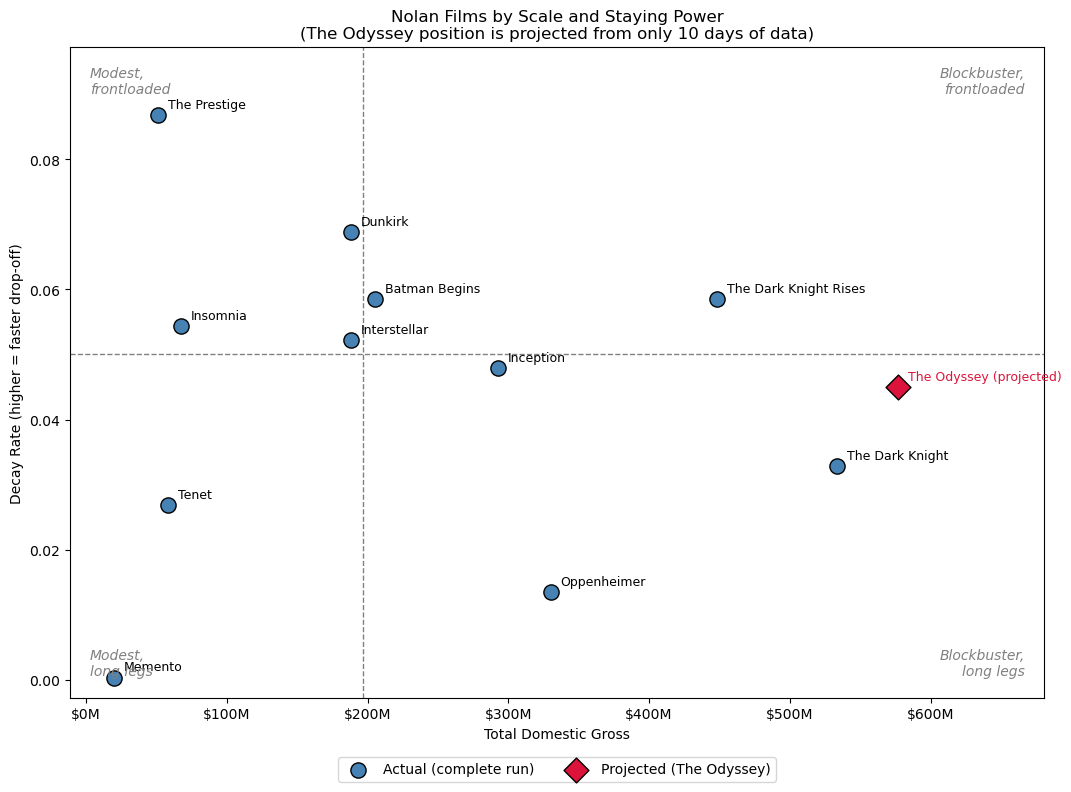

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

nolan = ['Memento', 'Insomnia', 'Batman Begins', 'The Prestige', 'The Dark Knight',
         'Inception', 'The Dark Knight Rises', 'Interstellar', 'Dunkirk', 'Tenet',
         'Oppenheimer']
rows = []
for title in nolan:
    d = df[df['title'] == title].sort_values('day_of_run')
    total_gross = d['cumulative_gross'].max()
    b, _ = np.polyfit(d['day_of_run'], np.log(d['daily_gross']), 1)
    rows.append({'title': title, 'total_gross': total_gross, 'decay_rate': -b, 'projected': False})

# --- The Odyssey: same anchored, weekly-erosion projection as the trajectory chart ---
ody = df[df['title'] == 'The Odyssey'].sort_values('day_of_run')
x = ody['day_of_run'].values
y = ody['daily_gross'].values
last_day = x[-1]
last_cum = ody['cumulative_gross'].values[-1]

b_ody, log_a = np.polyfit(x, np.log(y), 1)
a_ody = np.exp(log_a)

WEEKLY_EROSION = 0.75

project_days = np.arange(last_day + 1, 80)
week_number = (project_days - last_day - 1) // 7
projected_daily = a_ody * np.exp(b_ody * project_days) * (WEEKLY_EROSION ** week_number)
projected_total_gross = last_cum + projected_daily.sum()

rows.append({'title': 'The Odyssey (projected)', 'total_gross': projected_total_gross,
             'decay_rate': -b_ody, 'projected': True})

feat = pd.DataFrame(rows).set_index('title')
x_med = feat['total_gross'].median()
y_med = feat['decay_rate'].median()
fig, ax = plt.subplots(figsize=(11, 8))
actual = feat[~feat['projected']]
proj = feat[feat['projected']]
ax.scatter(actual['total_gross'], actual['decay_rate'], s=120, color='steelblue',
           edgecolor='black', zorder=3, label='Actual (complete run)')
ax.scatter(proj['total_gross'], proj['decay_rate'], s=160, color='crimson', marker='D',
           edgecolor='black', zorder=3, label='Projected (The Odyssey)')
for title, row in feat.iterrows():
    ax.annotate(title, (row['total_gross'], row['decay_rate']),
                textcoords="offset points", xytext=(7, 5), fontsize=9,
                color='crimson' if row['projected'] else 'black')
xpad = feat['total_gross'].max() * 0.18
ypad = feat['decay_rate'].max() * 0.12
ax.set_xlim(feat['total_gross'].min() - xpad*0.3, feat['total_gross'].max() + xpad)
ax.set_ylim(feat['decay_rate'].min() - ypad*0.3, feat['decay_rate'].max() + ypad)
ax.axvline(x_med, color='gray', ls='--', lw=1)
ax.axhline(y_med, color='gray', ls='--', lw=1)
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
pad_x = (xmax - xmin) * 0.02
pad_y = (ymax - ymin) * 0.03
ax.text(xmax - pad_x, ymax - pad_y, 'Blockbuster,\nfrontloaded', ha='right', va='top', fontsize=10, color='gray', style='italic')
ax.text(xmin + pad_x, ymax - pad_y, 'Modest,\nfrontloaded', ha='left', va='top', fontsize=10, color='gray', style='italic')
ax.text(xmax - pad_x, ymin + pad_y, 'Blockbuster,\nlong legs', ha='right', va='bottom', fontsize=10, color='gray', style='italic')
ax.text(xmin + pad_x, ymin + pad_y, 'Modest,\nlong legs', ha='left', va='bottom', fontsize=10, color='gray', style='italic')
ax.set_xlabel('Total Domestic Gross')
ax.set_ylabel('Decay Rate (higher = faster drop-off)')
ax.set_title(f'Nolan Films by Scale and Staying Power\n(The Odyssey position is projected from only {last_day} days of data)')
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'${v/1e6:,.0f}M'))
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2)
plt.tight_layout()
plt.savefig('quadrant_with_odyssey_only.png', dpi=150, bbox_inches='tight')

In [6]:
import pandas as pd

nolan = ['Memento', 'Insomnia', 'Batman Begins', 'The Prestige', 'The Dark Knight',
         'Inception', 'The Dark Knight Rises', 'Interstellar', 'Dunkirk', 'Tenet',
         'Oppenheimer', 'The Odyssey'] 

results = []
for title in nolan:
    d = df[df['title'] == title].sort_values('day_of_run').reset_index(drop=True)

    # tag each Fri/Sat/Sun with a weekend number (1st Fri-Sun found = weekend 1, etc.)
    d['is_weekend_day'] = d['dow'].isin(['Friday', 'Saturday', 'Sunday'])
    d['weekend_num'] = (d['dow'] == 'Friday').cumsum()
    weekend_sums = d[d['is_weekend_day']].groupby('weekend_num')['daily_gross'].sum()

    if len(weekend_sums) < 2:
        continue

    wknd1 = weekend_sums.iloc[0]
    wknd2 = weekend_sums.iloc[1]
    drop_pct = (wknd2 - wknd1) / wknd1 * 100

    results.append({'title': title, 'weekend_1': wknd1, 'weekend_2': wknd2, 'drop_pct': drop_pct})

res = pd.DataFrame(results).sort_values('drop_pct')

for _, r in res.iterrows():
    print(f"{r['title']:<25} wknd1: ${r['weekend_1']:>12,.0f}   wknd2: ${r['weekend_2']:>12,.0f}   drop: {r['drop_pct']:>6.3f}%")

The Dark Knight Rises     wknd1: $ 160,887,295   wknd2: $  62,101,451   drop: -61.401%
The Dark Knight           wknd1: $ 158,411,483   wknd2: $  75,166,466   drop: -52.550%
Insomnia                  wknd1: $  20,930,169   wknd2: $   9,945,321   drop: -52.483%
Dunkirk                   wknd1: $  50,513,488   wknd2: $  26,611,130   drop: -47.319%
Batman Begins             wknd1: $  48,745,440   wknd2: $  27,589,389   drop: -43.401%
Oppenheimer               wknd1: $  82,455,420   wknd2: $  46,705,630   drop: -43.357%
Interstellar              wknd1: $  47,510,360   wknd2: $  28,307,626   drop: -40.418%
The Prestige              wknd1: $  14,801,808   wknd2: $   9,573,215   drop: -35.324%
Inception                 wknd1: $  62,785,337   wknd2: $  42,725,012   drop: -31.951%
Tenet                     wknd1: $   9,353,090   wknd2: $   6,603,467   drop: -29.398%
The Odyssey               wknd1: $ 123,502,900   wknd2: $  90,022,510   drop: -27.109%
